# Step 1: Data Exploration, Stratified Sampling & Preprocessing Pipeline

**Capstone Project: IoT Intrusion Detection System (CICIoT2023)**

This notebook demonstrates:
1. Loading the stratified working dataset extracted from `MERGED_CSV/`.
2. Analyzing and visualizing class distributions across **2 classes (Binary)**, **8 classes (Category)**, and **34 classes (Fine-Grained)**.
3. Inspecting the 39 network flow features and verifying absence of missing values.
4. Applying the leak-free preprocessing and `StandardScaler` pipeline.

In [1]:
import sys
from pathlib import Path

# Ensure project root is in sys.path
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import (
    SAMPLE_FILE,
    FEATURE_COLUMNS,
    TARGET_COLUMN,
    LABEL_MAPPING_BINARY,
    LABEL_MAPPING_8CLASSES,
    BINARY_CLASSES,
    EIGHT_CLASSES,
    THIRTY_FOUR_CLASSES,
)
from src.preprocessing import prepare_dataset, encode_labels, clean_features

sns.set_theme(style="whitegrid", palette="muted")
print(f"Target sample path: {SAMPLE_FILE}")

Target sample path: C:\Users\priya\Downloads\capstone\data\sample_stratified.csv


## 1. Load the Stratified Sample

In [2]:
df = pd.read_csv(SAMPLE_FILE)
print(f"Sample Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Total Unique Classes: {df[TARGET_COLUMN].nunique()} of 34")
df.head()

Sample Shape: 529,562 rows x 40 columns
Total Unique Classes: 34 of 34


,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number,ack_flag_number,ece_flag_number,...,Tot sum,Min,Max,AVG,Std,Tot size,IAT,Number,Variance,Label
0,24.8,6.0,104.5,275.32340,0.0,0.0,0.0,0.2,1.0,0.0,...,6035.0,60.0,1214.0,603.5,550.760130,603.5,0.003632,10.0,3.033367e+05,BENIGN
1,22.0,6.0,131.9,636.08850,0.0,0.5,0.5,0.0,0.5,0.0,...,600.0,60.0,60.0,60.0,0.000000,60.0,0.001975,10.0,0.000000e+00,RECON-HOSTDISCOVERY
2,29.6,6.0,83.1,1950.83910,0.0,0.0,0.0,0.0,0.9,0.0,...,19648.0,230.0,4410.0,1964.8,1164.124500,1964.8,0.000530,10.0,1.355186e+06,BENIGN
3,28.8,6.0,208.8,349.55447,0.0,0.0,0.0,0.0,0.9,0.0,...,654.0,60.0,66.0,65.4,1.897367,65.4,0.002861,10.0,3.600000e+00,BENIGN
4,22.0,6.0,115.0,66.59866,0.1,0.0,0.0,0.3,0.7,0.0,...,968.0,60.0,214.0,96.8,51.635044,96.8,0.015016,10.0,2.666178e+03,RECON-PORTSCAN


## 2. Target Distribution Visualizations

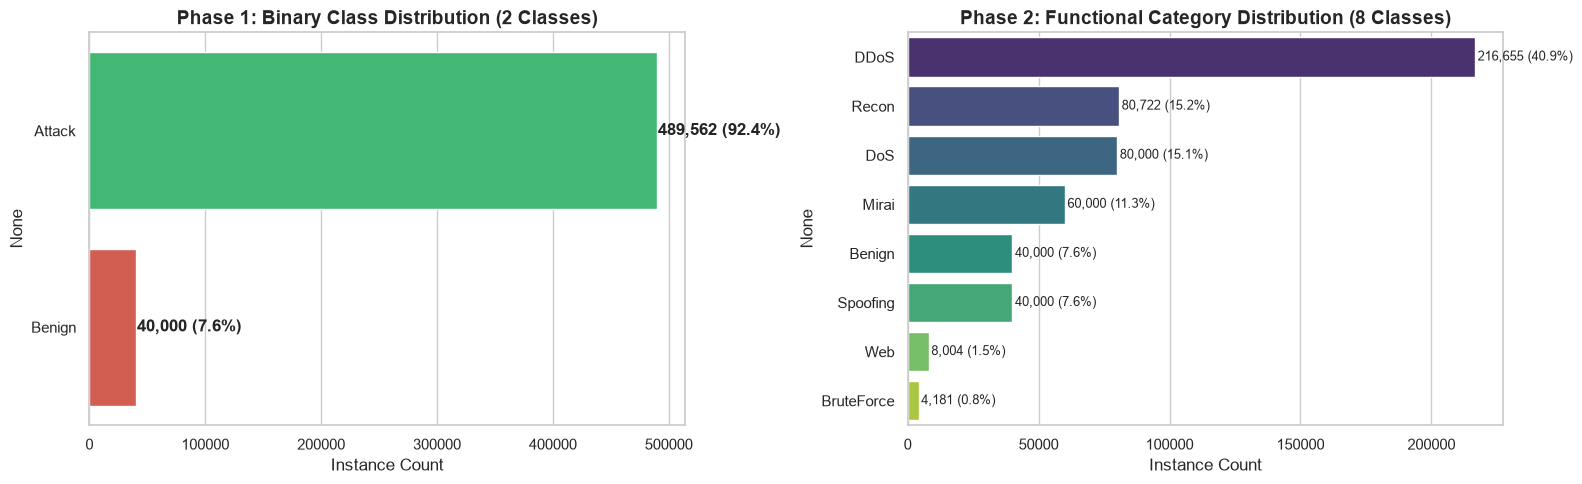

In [3]:
# 2-Class Target (Binary)
y_bin, _, bin_classes = encode_labels(df, target_type="binary")
df_bin = pd.Series(y_bin).map({0: "Benign", 1: "Attack"}).value_counts()

# 8-Class Target (Category)
y_cat, _, cat_classes = encode_labels(df, target_type="category")
df_cat = pd.Series(y_cat).map({i: c for i, c in enumerate(cat_classes)}).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Binary plot
sns.barplot(x=df_bin.values, y=df_bin.index, hue=df_bin.index, ax=axes[0], palette=["#2ecc71", "#e74c3c"], legend=False)
axes[0].set_title("Phase 1: Binary Class Distribution (2 Classes)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Instance Count")
for i, v in enumerate(df_bin.values):
    pct = (v / len(df)) * 100
    axes[0].text(v + 1000, i, f"{v:,} ({pct:.1f}%)", va="center", fontweight="bold")

# 8-Class plot
sns.barplot(x=df_cat.values, y=df_cat.index, hue=df_cat.index, ax=axes[1], palette="viridis", legend=False)
axes[1].set_title("Phase 2: Functional Category Distribution (8 Classes)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Instance Count")
for i, v in enumerate(df_cat.values):
    pct = (v / len(df)) * 100
    axes[1].text(v + 1000, i, f"{v:,} ({pct:.1f}%)", va="center", fontsize=9)

plt.tight_layout()
plt.show()

### 34-Class Fine-Grained Target Distribution

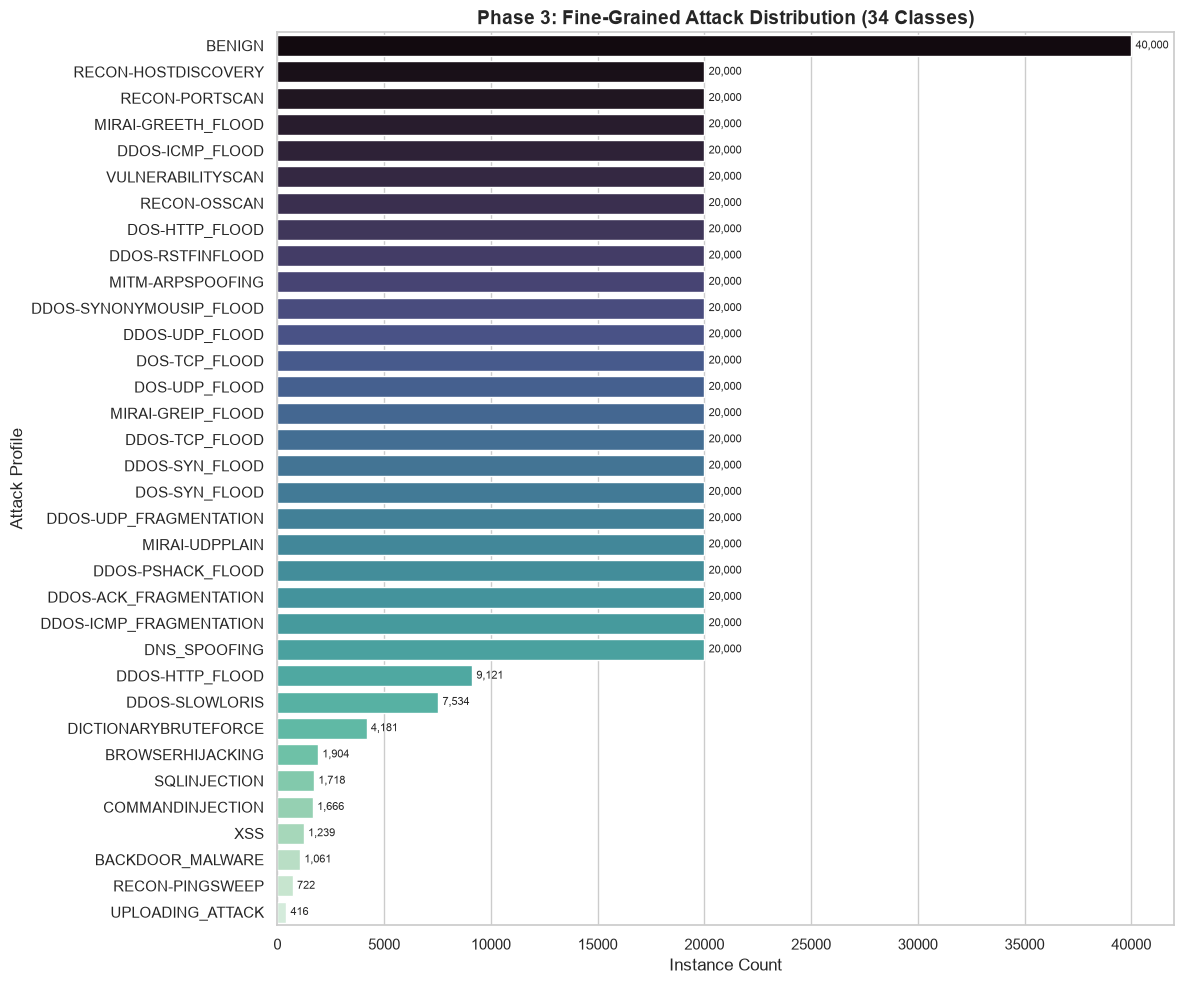

In [4]:
plt.figure(figsize=(12, 10))
class_counts = df[TARGET_COLUMN].value_counts()
sns.barplot(x=class_counts.values, y=class_counts.index, hue=class_counts.index, palette="mako", legend=False)
plt.title("Phase 3: Fine-Grained Attack Distribution (34 Classes)", fontsize=14, fontweight="bold")
plt.xlabel("Instance Count")
plt.ylabel("Attack Profile")
for i, v in enumerate(class_counts.values):
    plt.text(v + 200, i, f"{v:,}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

## 3. Feature Verification and Integrity Check

In [5]:
print(f"Verifying {len(FEATURE_COLUMNS)} input features:")
missing_counts = df[FEATURE_COLUMNS].isnull().sum()
print(f"Missing values across all features: {missing_counts.sum()}")

# Summary statistics of first 8 features
df[FEATURE_COLUMNS[:8]].describe().T[['count', 'mean', 'std', 'min', 'max']]

Verifying 39 input features:
Missing values across all features: 32


C:\Users\priya\Downloads\capstone\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,max
Header_Length,529562.0,16.918144,10.735547,0.000000,60.0
Protocol Type,529562.0,10.928029,11.325131,0.000000,47.0
Time_To_Live,529562.0,76.724325,31.547768,0.000000,255.0
Rate,529562.0,inf,NaN,0.000156,inf
fin_flag_number,529562.0,0.047522,0.192134,0.000000,1.0
syn_flag_number,529562.0,0.160071,0.332000,0.000000,1.0
rst_flag_number,529562.0,0.073319,0.229144,0.000000,1.0
psh_flag_number,529562.0,0.104179,0.219971,0.000000,1.0


## 4. Test Preprocessing Pipeline (Train/Test Split & Scaling)

In [6]:
# Demonstrate pipeline for Binary classification
X_train, X_test, y_train, y_test, class_names, scaler = prepare_dataset(
    df, target_type="binary", test_size=0.2, random_state=42, scale_features=True
)

print(f"X_train Shape : {X_train.shape} | y_train Shape: {y_train.shape}")
print(f"X_test Shape  : {X_test.shape}  | y_test Shape : {y_test.shape}")
print(f"Classes: {class_names}")
print(f"Train Label Distribution: {dict(pd.Series(y_train).value_counts())}")
print(f"Test Label Distribution : {dict(pd.Series(y_test).value_counts())}")

# Verify normalization: Mean should be ~0 and Std ~1
print(f"\nX_train Mean (first 5 features): {np.round(X_train[:, :5].mean(axis=0), 4)}")
print(f"X_train Std  (first 5 features): {np.round(X_train[:, :5].std(axis=0), 4)}")

X_train Shape : (423649, 39) | y_train Shape: (423649,)
X_test Shape  : (105913, 39)  | y_test Shape : (105913,)
Classes: ['Benign', 'Attack']
Train Label Distribution: {1: np.int64(391649), 0: np.int64(32000)}
Test Label Distribution : {1: np.int64(97913), 0: np.int64(8000)}

X_train Mean (first 5 features): [-0.  0. -0. -0.  0.]
X_train Std  (first 5 features): [1.0004 0.9994 0.9992 0.9997 1.0003]
